--- Part A: Initiation + 1 Cycle ---
Production rate at cycle 1: 73.30 g/hr


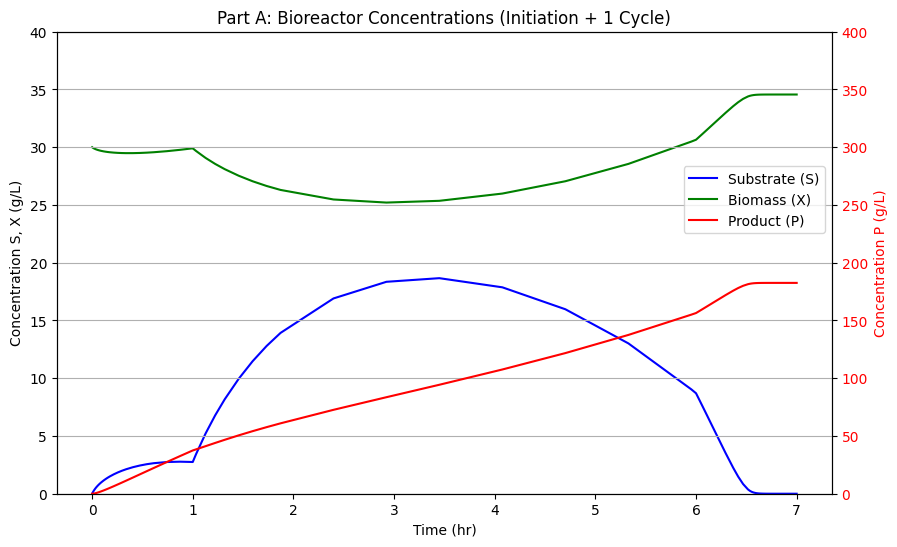


--- Part B: Initiation + 10 Cycles ---
Production rate at cycle 10: 99.95 g/hr


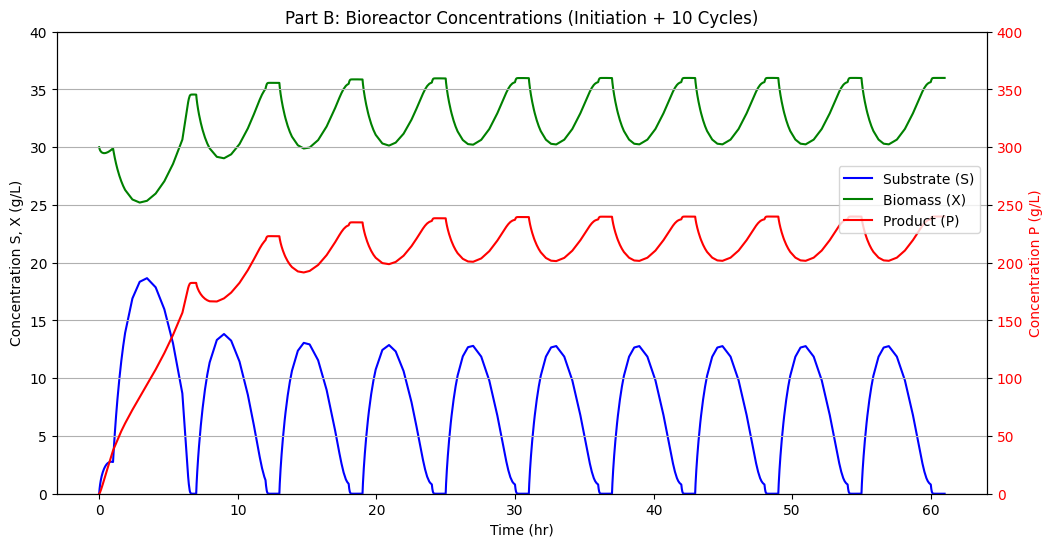

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
mu_max = 0.3      # h^-1
Ks = 0.8          # g/L
Ki = 100.0        # g/L
Yxs = 0.45        # g/g
Yxp = 0.15        # g/g

# Feed concentrations
S0_feed = 80.0    # g/L
Sp_feed = 80.0    # g/L

# Flow rates
Fi = 0.2          # L/h
Fp = 0.5          # L/h
Fh = 2.5          # L/h

# Kinetic Model 
def mu_net(S):
    # Uncompetitive substrate inhibition
    return (mu_max * S) / (Ks + S + (S**2 / Ki))



# ODE System 
# y = [Nx, Ns, Np, V, M_harvested]
def bioreactor_odes(t, y, phase):
    Nx, Ns, Np, V, M_harv = y
    
    # Calculate concentrations
    X = Nx / V
    S = max(0, Ns / V) # Prevent negative concentrations in numerical steps
    P = Np / V
    
    # Kinetics
    mu = mu_net(S)
    
    # Defaults for phases
    Fin = 0.0
    Sin = 0.0
    Fout = 0.0
    
    if phase == 'initiation':
        Fin = Fi
        Sin = S0_feed
    elif phase == 'processing':
        Fin = Fp
        Sin = Sp_feed
    elif phase == 'harvesting':
        Fout = Fh
        
    # Differential Equations based on the provided table
    dV_dt = Fin - Fout
    dNx_dt = -Fout * X + mu * Nx
    dNs_dt = Fin * Sin - Fout * S - (mu * Nx) / Yxs
    dNp_dt = -Fout * P + (mu * Nx) / Yxp
    dMharv_dt = Fout * P # Track total mass of product harvested
    
    return [dNx_dt, dNs_dt, dNp_dt, dV_dt, dMharv_dt]


def simulate_cycles(num_cycles):
    # Initial conditions at t=0
    V_initial = 0.85
    X_initial = 30.0
    y0 = [X_initial * V_initial, 0.0, 0.0, V_initial, 0.0] # [Nx, Ns, Np, V, M_harvested]

    t_results = []
    y_results = []
    
    current_t = 0.0
    # Initiation Phase (t=0 to t=1)
    sol = solve_ivp(bioreactor_odes, [current_t, 1.0], y0, method='BDF', args=('initiation',), dense_output=True)
    t_results.append(sol.t)
    y_results.append(sol.y)
    current_t = 1.0
    y0 = sol.y[:, -1]
    
    # Cyclic Phases (Processing + Harvesting)
    for cycle in range(num_cycles):
        # Reset the harvested mass counter at the start of each cycle to track per-cycle yield
        y0[4] = 0.0 # Reset M_harvested for the new cycle
        
        # Processing Phase (5 hours)
        t_end_proc = current_t + 5.0
        sol_proc = solve_ivp(bioreactor_odes, [current_t, t_end_proc], y0, method='BDF', args=('processing',), dense_output=True)
        t_results.append(sol_proc.t)
        y_results.append(sol_proc.y)
        current_t = t_end_proc
        y0 = sol_proc.y[:, -1]
        
        # Harvesting Phase (1 hour)
        t_end_harv = current_t + 1.0
        sol_harv = solve_ivp(bioreactor_odes, [current_t, t_end_harv], y0, method='BDF', args=('harvesting',), dense_output=True)
        t_results.append(sol_harv.t)
        y_results.append(sol_harv.y)
        current_t = t_end_harv
        y0 = sol_harv.y[:, -1]
        
        # If it's the last cycle, calculate the production rate
        if cycle == num_cycles - 1:
            mass_harvested = y0[4]
            cycle_time = 6.0 # 5h processing + 1h harvesting
            production_rate = mass_harvested / cycle_time
            print(f"Production rate at cycle {cycle+1}: {production_rate:.2f} g/hr")

    # Concatenate all results
    t_all = np.concatenate(t_results)
    y_all = np.concatenate(y_results, axis=1)
    
    return t_all, y_all

# --- Part A: 1 Cycle Simulation ---
print("--- Part A: Initiation + 1 Cycle ---")
t_1, y_1 = simulate_cycles(1)

# Calculate concentrations
V_1 = y_1[3]
X_1 = y_1[0] / V_1
S_1 = y_1[1] / V_1
P_1 = y_1[2] / V_1

# Plot Part A
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(t_1, S_1, 'b-', label='Substrate (S)')
ax1.plot(t_1, X_1, 'g-', label='Biomass (X)')
ax1.set_xlabel('Time (hr)')
ax1.set_ylabel('Concentration S, X (g/L)')
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.plot(t_1, P_1, 'r-', label='Product (P)')
ax2.set_ylabel('Concentration P (g/L)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

ax1.set_ylim(0, 40)   # To not have an overlap of the y-axes
ax2.set_ylim(0, 400)

fig.legend(loc="center right", bbox_to_anchor=(0.9,0.6))
plt.title('Part A: Bioreactor Concentrations (Initiation + 1 Cycle)')
plt.grid(True)
plt.show()

# --- Part B: 10 Cycles Simulation ---
print("\n--- Part B: Initiation + 10 Cycles ---")
t_10, y_10 = simulate_cycles(10)

# Calculate concentrations
V_10 = y_10[3]
X_10 = y_10[0] / V_10
S_10 = y_10[1] / V_10
P_10 = y_10[2] / V_10

# Plot Part B
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(t_10, S_10, 'b-', label='Substrate (S)')
ax1.plot(t_10, X_10, 'g-', label='Biomass (X)')
ax1.set_xlabel('Time (hr)')
ax1.set_ylabel('Concentration S, X (g/L)')
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.plot(t_10, P_10, 'r-', label='Product (P)')
ax2.set_ylabel('Concentration P (g/L)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

ax1.set_ylim(0, 40)   # To not have an overlap of the y-axes
ax2.set_ylim(0, 400)

fig.legend(loc="center right", bbox_to_anchor=(0.9,0.6))
plt.title('Part B: Bioreactor Concentrations (Initiation + 10 Cycles)')
plt.grid(True)
plt.show()